 CSV file loaded successfully!

Preview of data before cleaning:
         Date and Time  Temperature (°C)  Humidity (%)  windspeed (m/s)
0  2025-10-21 00:00:00              23.5            83              2.4
1  2025-10-21 01:00:00              23.6            83              5.1
2  2025-10-21 02:00:00              23.4            85              3.6
3  2025-10-21 03:00:00              25.6            74              4.0
4  2025-10-21 04:00:00              27.4            65              5.5 

 Cleaned Data Preview:
                 Date  Temperature  Humidity  WindSpeed
0 2025-10-21 00:00:00         23.5        83        2.4
1 2025-10-21 01:00:00         23.6        83        5.1
2 2025-10-21 02:00:00         23.4        85        3.6
3 2025-10-21 03:00:00         25.6        74        4.0
4 2025-10-21 04:00:00         27.4        65        5.5 

 Basic Statistical Summary:

                                Date  Temperature   Humidity   WindSpeed
count                            168  

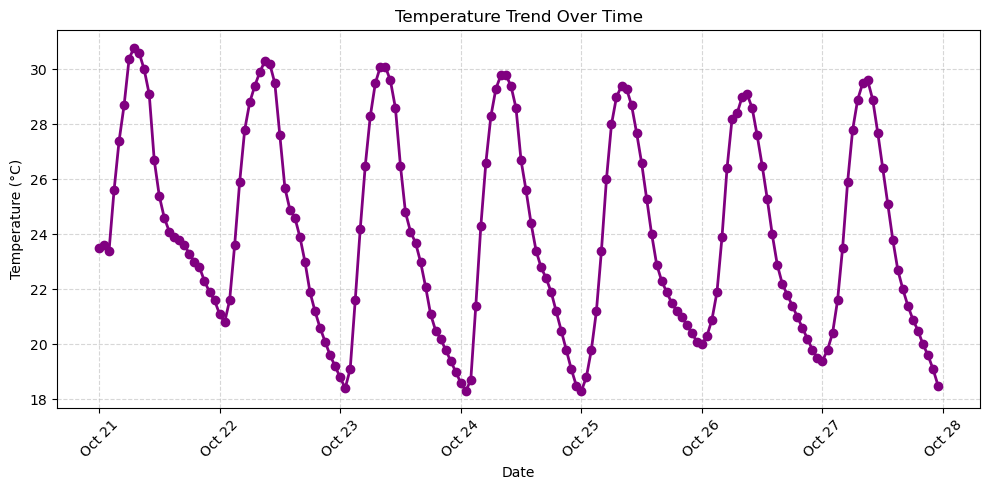

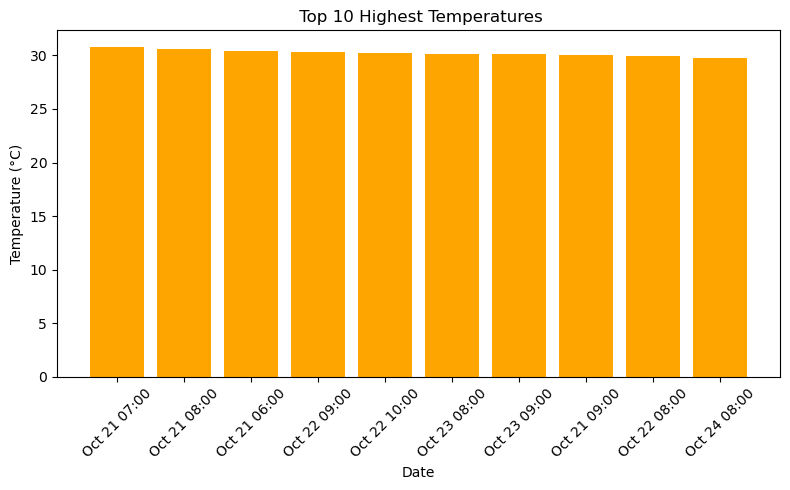

Minimum Temperature: 18.3 °C
Maximum Temperature: 30.8 °C



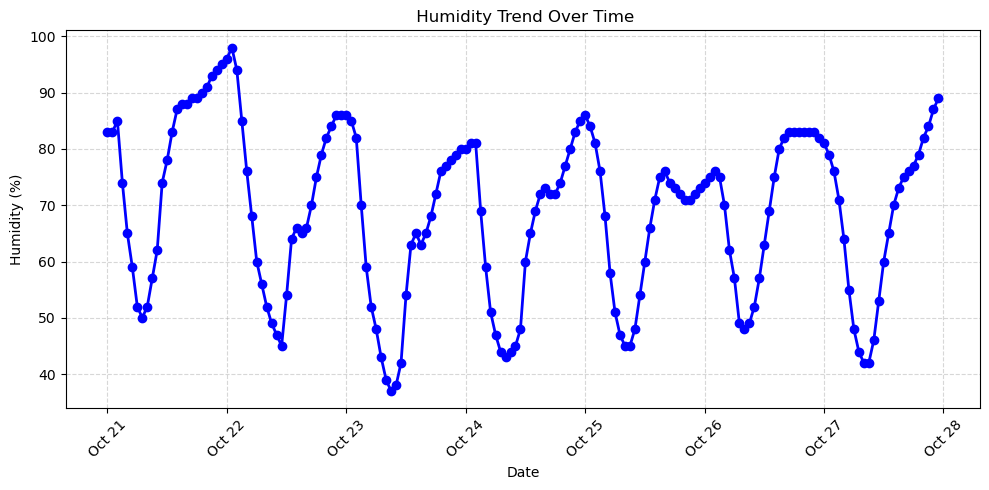

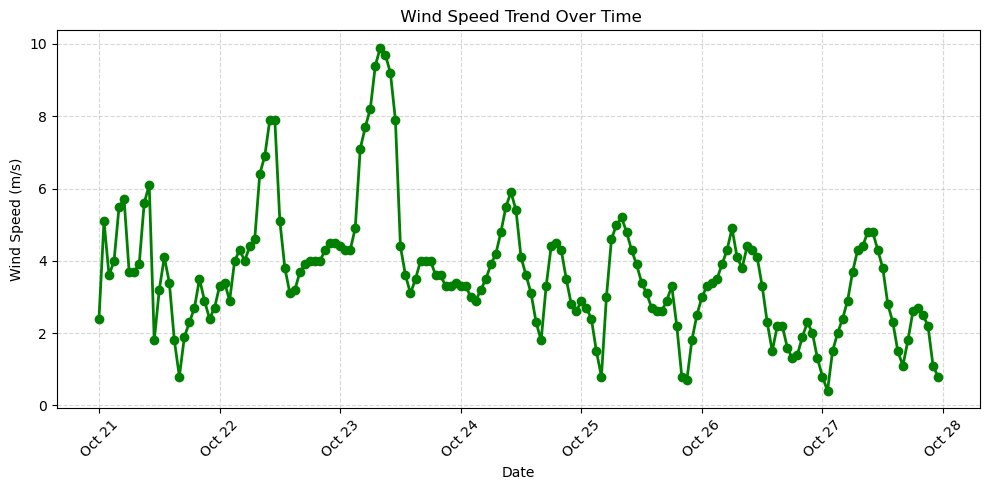

In [15]:
# CSV TO INSIGHTS DASHBOARD

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


try:
    # Change the file name to your actual CSV file name
    df = pd.read_csv("Delhi_weather.csv")
    print(" CSV file loaded successfully!\n")
except FileNotFoundError:
    print(" File not found. Please check your file path.")
    df = None



if df is not None:
    print("Preview of data before cleaning:")
    print(df.head(), "\n")

    # Rename columns if necessary (matches Project 1 output)
    df.rename(columns={
        'Date and Time': 'Date',
        'Temperature (°C)': 'Temperature',
         'Humidity (%)': 'Humidity',
        'windspeed (m/s)': 'WindSpeed'
    }, inplace=True)

    # Convert date column to datetime type
    df['Date'] = pd.to_datetime(df['Date'])

    # Drop missing values
    df.dropna(inplace=True)

    print(" Cleaned Data Preview:")
    print(df.head(), "\n")

    
    #  Basic Data Insights

    print(" Basic Statistical Summary:\n")
    print(df.describe(), "\n")
    
    # Data Visualization
    

    ## Temperature Trend Over Time
    if 'Date' in df.columns and 'Temperature' in df.columns:
        plt.figure(figsize=(10,5))
        plt.plot(df['Date'], df['Temperature'], color='purple', marker='o', linewidth=2)
        plt.title('Temperature Trend Over Time')
        plt.xlabel('Date')
        plt.ylabel('Temperature (°C)')
        plt.grid(True, linestyle='--', alpha=0.5)

        # Fixing overlapping date labels
        plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(" 'Date' or 'Temperature' column not found for trend plot.\n")
        
    ## Top 10 Highest Temperatures
    if 'Temperature' in df.columns:
        top10 = df.nlargest(10, 'Temperature')
        plt.figure(figsize=(8,5))
        plt.bar(top10['Date'].dt.strftime('%b %d %H:%M'), top10['Temperature'], color='orange')
        plt.title(' Top 10 Highest Temperatures')
        plt.xlabel('Date')
        plt.ylabel('Temperature (°C)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    
    ## Min & Max Temperature
    if 'Temperature' in df.columns:
        print(f"Minimum Temperature: {df['Temperature'].min()} °C")
        print(f"Maximum Temperature: {df['Temperature'].max()} °C\n")

    
    ## Humidity Trend
    if 'Humidity' in df.columns:
        plt.figure(figsize=(10,5))
        plt.plot(df['Date'], df['Humidity'], color='blue', marker='o', linewidth=2)
        plt.title(' Humidity Trend Over Time')
        plt.xlabel('Date')
        plt.ylabel('Humidity (%)')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    
    ## Wind Speed Trend
    if 'WindSpeed' in df.columns:
        plt.figure(figsize=(10,5))
        plt.plot(df['Date'], df['WindSpeed'], color='green', marker='o', linewidth=2)
        plt.title(' Wind Speed Trend Over Time')
        plt.xlabel('Date')
        plt.ylabel('Wind Speed (m/s)')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

else:
    print(" No data to process.")
